In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font", family='Microsoft YaHei')

# 读取数据
samples_data_Bearing1_1 = pd.read_csv('./dataresult/samples_data_Bearing1_1.csv')
samples_data_Bearing1_2 = pd.read_csv('./dataresult/samples_data_Bearing1_2.csv')
samples_data_Bearing1_3 = pd.read_csv('./dataresult/samples_data_Bearing1_3.csv')

print(samples_data_Bearing1_3.shape)
samples_data_Bearing1_3.head()

(2375, 14)


,Kurtosis,Entropy,Fractal Dimension,Peak factor,Pulse factor,Crest factor,Energy ratio,Spectral flatness,Mean,Variance,Skewness,Peak vibration,Rms vibration,rul
0,0.068604,0,0.569557,3.556165,4.453893,3.556165,0.274037,0.281898,0.001171,0.172736,-0.004453,1.478,0.415616,0.999579
1,0.196395,0,0.525584,3.868142,4.871995,3.868142,0.306401,0.325227,-0.000061,0.152994,0.027562,1.513,0.391144,0.999158
2,0.380518,0,0.571110,4.116510,5.265177,4.116510,0.302070,0.324532,0.012603,0.151290,0.073442,1.602,0.389165,0.998737
3,0.489310,0,0.558032,4.266161,5.410227,4.266161,0.298705,0.316709,0.008862,0.144831,-0.092060,1.624,0.380670,0.998316
4,0.268491,0,0.548044,3.979449,5.046988,3.979449,0.302866,0.319473,0.004432,0.160628,-0.054019,1.595,0.400809,0.997895


### 可视化 Bearing1_3 最后一列为 目标预测值！

findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsof

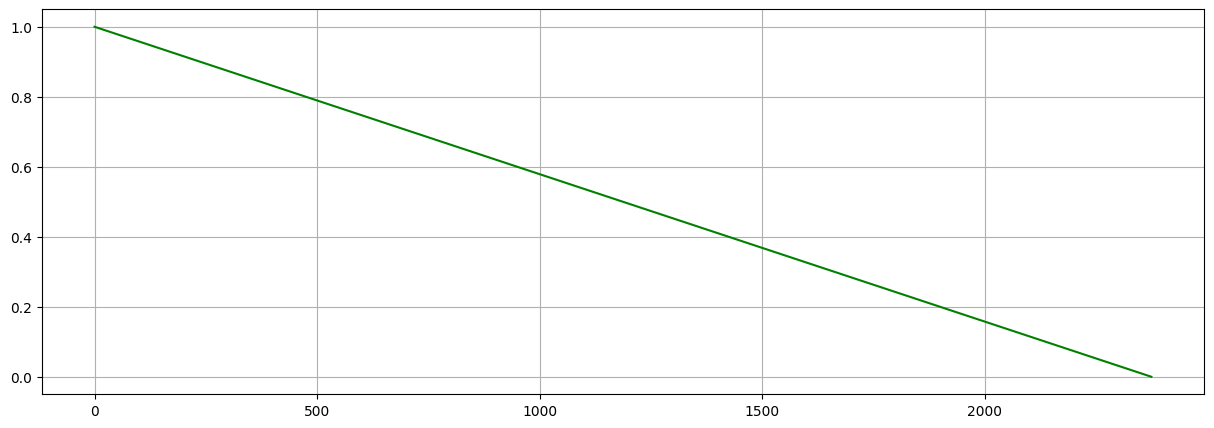

In [2]:
import pandas as pd
import datetime

# 取剩余寿命
ruldata = samples_data_Bearing1_3['rul'].tolist()
# 可视化
plt.figure(figsize=(15,5), dpi=100)
plt.grid(True)
plt.plot(ruldata, color='green')
plt.show()

In [3]:
# 制作数据集和标签
import torch
import numpy as np
import pandas as pd
from joblib import dump, load
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 选取 数值 型 变量
Bearing1_1 = samples_data_Bearing1_1.values
Bearing1_2 = samples_data_Bearing1_2.values
Bearing1_3 = samples_data_Bearing1_3.values

# 1. 输入训练集  变量：
var_data1 =  Bearing1_1
var_data2 =  Bearing1_2
# 测试集变量
var_data3 =  Bearing1_3

# 2. 对应y值标签为： 
ylable_data1 =  samples_data_Bearing1_1[['rul']].values
ylable_data2 =  samples_data_Bearing1_2[['rul']].values
ylable_data3 =  samples_data_Bearing1_3[['rul']].values

# 归一化处理
# 使用标准化（z-score标准化）
scaler = StandardScaler()
var_data1 = scaler.fit_transform(var_data1)
var_data2 = scaler.fit_transform(var_data2)
var_data3 = scaler.fit_transform(var_data3)


# 这些转换是为了将数据和标签转换为PyTorch可以处理的张量
def make_data_labels(x_data, y_label):
    '''
        返回 x_data: 数据集     torch.tensor
            y_label: 对应标签值  torch.tensor
    '''
    # 信号值
    x_data = torch.tensor(x_data).float()
    # 标签值
    y_label = torch.tensor(y_label).float()
    return x_data, y_label


# 使用滑动窗口处理时间序列数据
def data_window_maker(x_var, ylable_data, window_size):
    '''
        参数:
        x_var      : 输入 变量数据
        ylable_data: 对应y数据
        window_size: 滑动窗口大小

        返回:
        data_x: 特征数据
        data_y: 标签数据
    '''
    # 用来存放输入特征
    data_x = []
    # 用来存放输出标签
    data_y = []
    # 构建训练集和对应标签
    data_len = x_var.shape[0] # 序列长度
    for i in range(data_len - window_size):
        data_x.append(x_var[i:i+window_size, :])  # 取前window_size个数据作为输入特征
        data_y.append(ylable_data[i+window_size])  # 取第window_size+1个数据作为输出标签
    # 将列表转换为单一的NumPy数组
    data_x = np.array(data_x)
    data_y = np.array(data_y)
    # 转换为 tensor
    data_x, data_y = make_data_labels(data_x, data_y)
    return data_x, data_y


# 定义滑动窗口大小
window_size = 1    # 自己定义


# 第二步 制作数据集
# Bearing1_1 、 Bearing1_2 作为训练集
train_set1, train_label1 = data_window_maker(var_data1, ylable_data1, window_size)
train_set2, train_label2 = data_window_maker(var_data2, ylable_data2, window_size)


# 在第一个维度上拼接
train_set = torch.cat((train_set1, train_set2), dim=0)
train_label = torch.cat((train_label1, train_label2), dim=0)

# 测试集
test_set, test_label = data_window_maker(var_data3, ylable_data3, window_size)

# 保存数据
dump(train_set, './dataresult/train_set') 
dump(train_label, './dataresult/train_label') 
dump(test_set, './dataresult/test_set') 
dump(test_label, './dataresult/test_label')

['./dataresult/test_label']

In [4]:
print('数据 形状：')
print(train_set.size(), train_label.size())
print(test_set.size(), test_label.size())
# 变量 序列长度为 10 , 预测一个 值 （单步预测）

数据 形状：
torch.Size([3672, 1, 14]) torch.Size([3672, 1])
torch.Size([2374, 1, 14]) torch.Size([2374, 1])
